# Market Making — Numerical Illustrations

This notebook supports chapters *Market Making Fundamentals* and *Optimal Market Making*. It covers:

1. **Grossman-Miller model**: inventory-risk spread vs competition, volatility, trade size and risk aversion.
2. **Glosten-Milgrom model**: information-asymmetry spread vs informed fraction.
3. **AS/GLF parameter sensitivities**: static spread and skew coefficient vs all model parameters in one consolidated figure.
4. **AS Backtesting** (following Avellaneda & Stoikov 2008): single simulated day comparing GLF stationary strategy vs single-trade EOD-liquidation strategy vs unmanaged symmetric quotes.
5. **Monte Carlo P&L distributions**: daily P&L distributions across 500 simulated paths for each strategy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'lines.linewidth': 1.5,
})

# Baseline AS parameters (Avellaneda-Stoikov 2008)
S0    = 100.0   # initial mid-price
SIGMA = 2.0     # price volatility ($/unit-time)
A     = 140     # Poisson arrival rate (orders/unit-time per side)
K     = 1.5     # demand elasticity (per $ half-spread)
GAMMA = 0.1     # CARA risk-aversion coefficient
T     = 1.0     # trading horizon (normalised to 1)

# Derived GLF constants
ETA   = np.log(1 + GAMMA / K) / GAMMA            # static half-spread η
THETA = GAMMA * SIGMA**2 / np.sqrt(2 * A * np.log(1 + GAMMA / K))  # skew coeff θ

print(f"η  = {ETA:.4f}   →   static spread 2η = {2*ETA:.4f}")
print(f"θ  = {THETA:.4f}")

η  = 0.6454   →   static spread 2η = 1.2908
θ  = 0.0941


## 1. Grossman-Miller Inventory Model

The equilibrium bid-ask spread in the Grossman-Miller (1988) three-period model is:
$$\text{spread}_{\text{GM}} = \frac{2\, i\, \gamma\, \sigma^2}{n}$$
We show all four parameter sensitivities in a single consolidated figure.

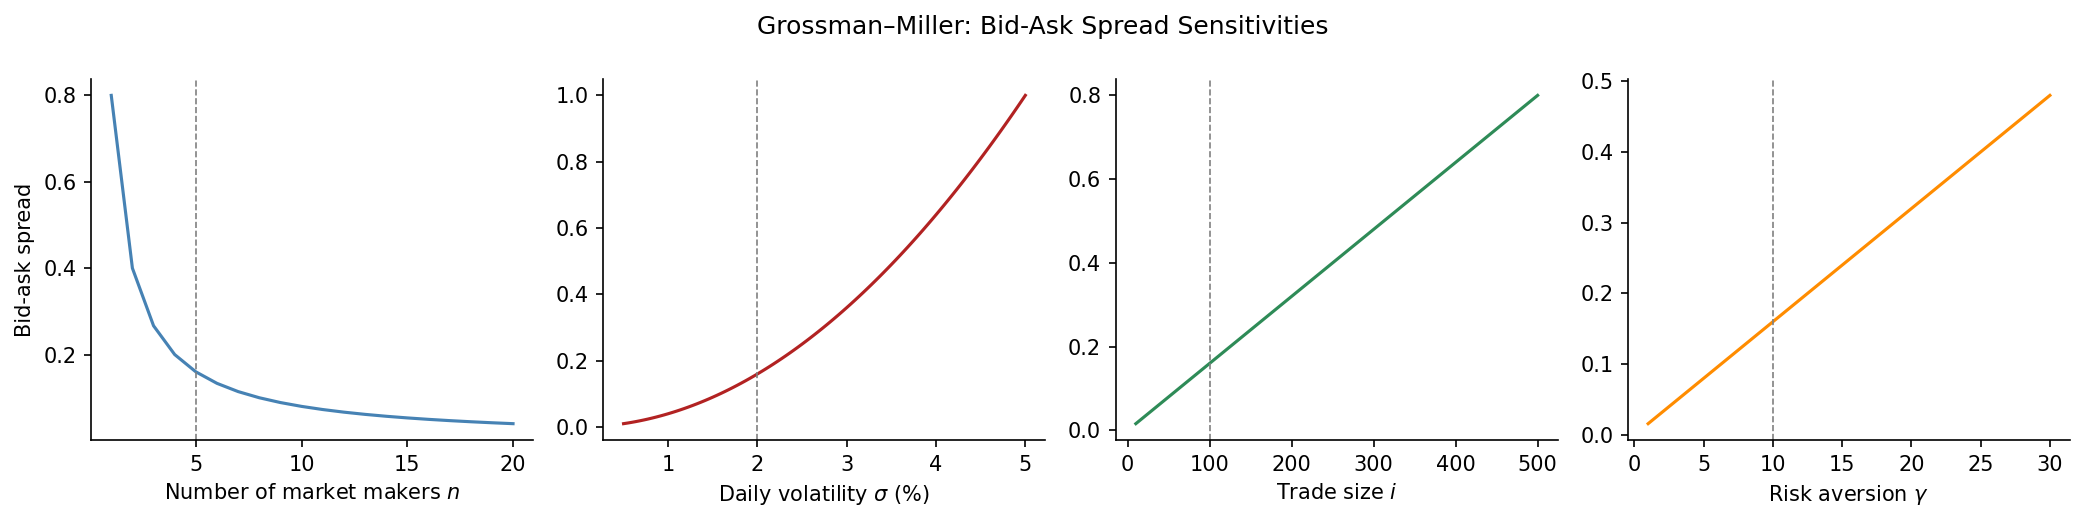

In [2]:
def gm_spread(i, gamma, sigma, n):
    return 2 * i * gamma * sigma**2 / n

i0, g0, s0, n0 = 100, 10, 0.02, 5

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
fig.suptitle('Grossman–Miller: Bid-Ask Spread Sensitivities', fontsize=12)

configs = [
    (np.arange(1, 21),          'steelblue',  'Number of market makers $n$',   None,   lambda x: gm_spread(i0, g0, s0, x), n0),
    (np.linspace(0.005,0.05,100),'firebrick', 'Daily volatility $\\sigma$ (%)', 100,    lambda x: gm_spread(i0, g0, x, n0), s0),
    (np.linspace(10,500,100),    'seagreen',  'Trade size $i$',                  1,     lambda x: gm_spread(x, g0, s0, n0), i0),
    (np.linspace(1,30,100),      'darkorange','Risk aversion $\\gamma$',          1,     lambda x: gm_spread(i0, x, s0, n0), g0),
]

ylabels = ['Bid-ask spread'] + [''] * 3
for ax, (xv, col, xl, xscale, fn, baseline), yl in zip(axes, configs, ylabels):
    yv = fn(xv)
    ax.plot(xv * (xscale or 1), yv, color=col)
    ax.axvline(baseline * (xscale or 1), color='gray', lw=0.8, ls='--')
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)

plt.tight_layout()
plt.savefig('../markdown/figures/mm_gm_sensitivities.png', bbox_inches='tight')
plt.show()

## 2. Glosten-Milgrom Information Asymmetry Model

In the symmetric ($p=\tfrac{1}{2}$) Glosten-Milgrom (1985) model:
$$a = \mu + \alpha(V_H-\mu),\quad b = \mu - \alpha(\mu-V_L), \quad \text{spread}_{\text{GL}} = \alpha(V_H-V_L)$$

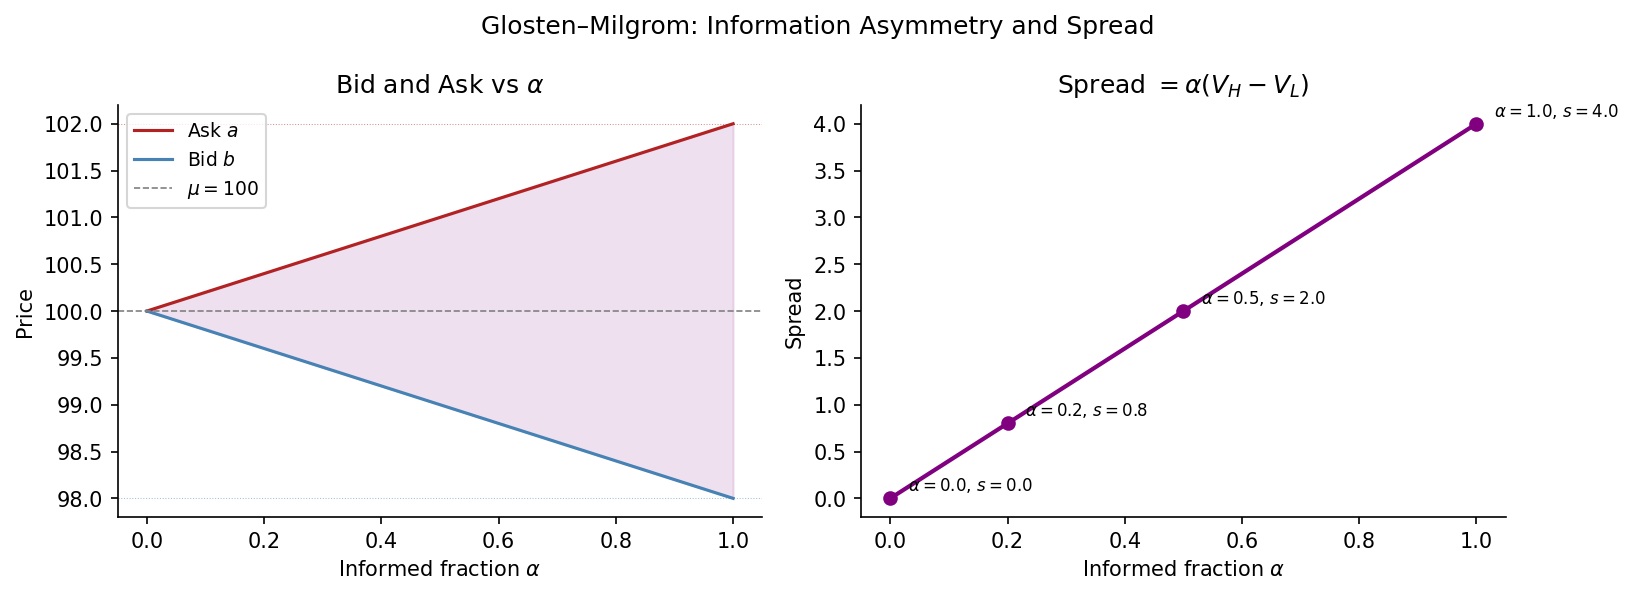

In [3]:
V_H, V_L, p_prior = 102.0, 98.0, 0.5
mu = p_prior * V_H + (1 - p_prior) * V_L
alpha_vals = np.linspace(0, 1, 300)

ask_v = mu + alpha_vals * (V_H - mu)
bid_v = mu - alpha_vals * (mu - V_L)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Glosten–Milgrom: Information Asymmetry and Spread', fontsize=12)

ax = axes[0]
ax.plot(alpha_vals, ask_v, color='firebrick', label='Ask $a$')
ax.plot(alpha_vals, bid_v, color='steelblue', label='Bid $b$')
ax.fill_between(alpha_vals, bid_v, ask_v, alpha=0.12, color='purple')
ax.axhline(mu, color='gray', lw=0.8, ls='--', label=f'$\\mu={mu:.0f}$')
ax.axhline(V_H, color='firebrick', lw=0.5, ls=':', alpha=0.5)
ax.axhline(V_L, color='steelblue', lw=0.5, ls=':', alpha=0.5)
ax.set_xlabel('Informed fraction $\\alpha$')
ax.set_ylabel('Price')
ax.set_title('Bid and Ask vs $\\alpha$')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(alpha_vals, ask_v - bid_v, color='purple', lw=2)
for am in [0.0, 0.2, 0.5, 1.0]:
    s = am * (V_H - V_L)
    ax.plot(am, s, 'o', color='purple', ms=6)
    ax.annotate(f'$\\alpha={am}$, $s={s:.1f}$', (am, s),
                xytext=(am+0.03, s+0.08), fontsize=8)
ax.set_xlabel('Informed fraction $\\alpha$')
ax.set_ylabel('Spread')
ax.set_title('Spread $= \\alpha(V_H - V_L)$')

plt.tight_layout()
plt.savefig('../markdown/figures/mm_gl_spread.png', bbox_inches='tight')
plt.show()

## 3. Avellaneda–Stoikov / GLF: Parameter Sensitivities

The Guéant-Lehalle-Fernández-Tapia stationary approximation gives:
- **Static half-spread**: $\eta = \frac{1}{\gamma}\ln\!\left(1+\frac{\gamma}{k}\right)$
- **Skew coefficient**: $\theta = \frac{\gamma\sigma^2}{\sqrt{2A\ln(1+\gamma/k)}}$
- **Optimal quotes**: $p^{a*} = S + \eta - \theta q$, $p^{b*} = S - \eta - \theta q$

The figure below collects all key parameter dependences in one view.

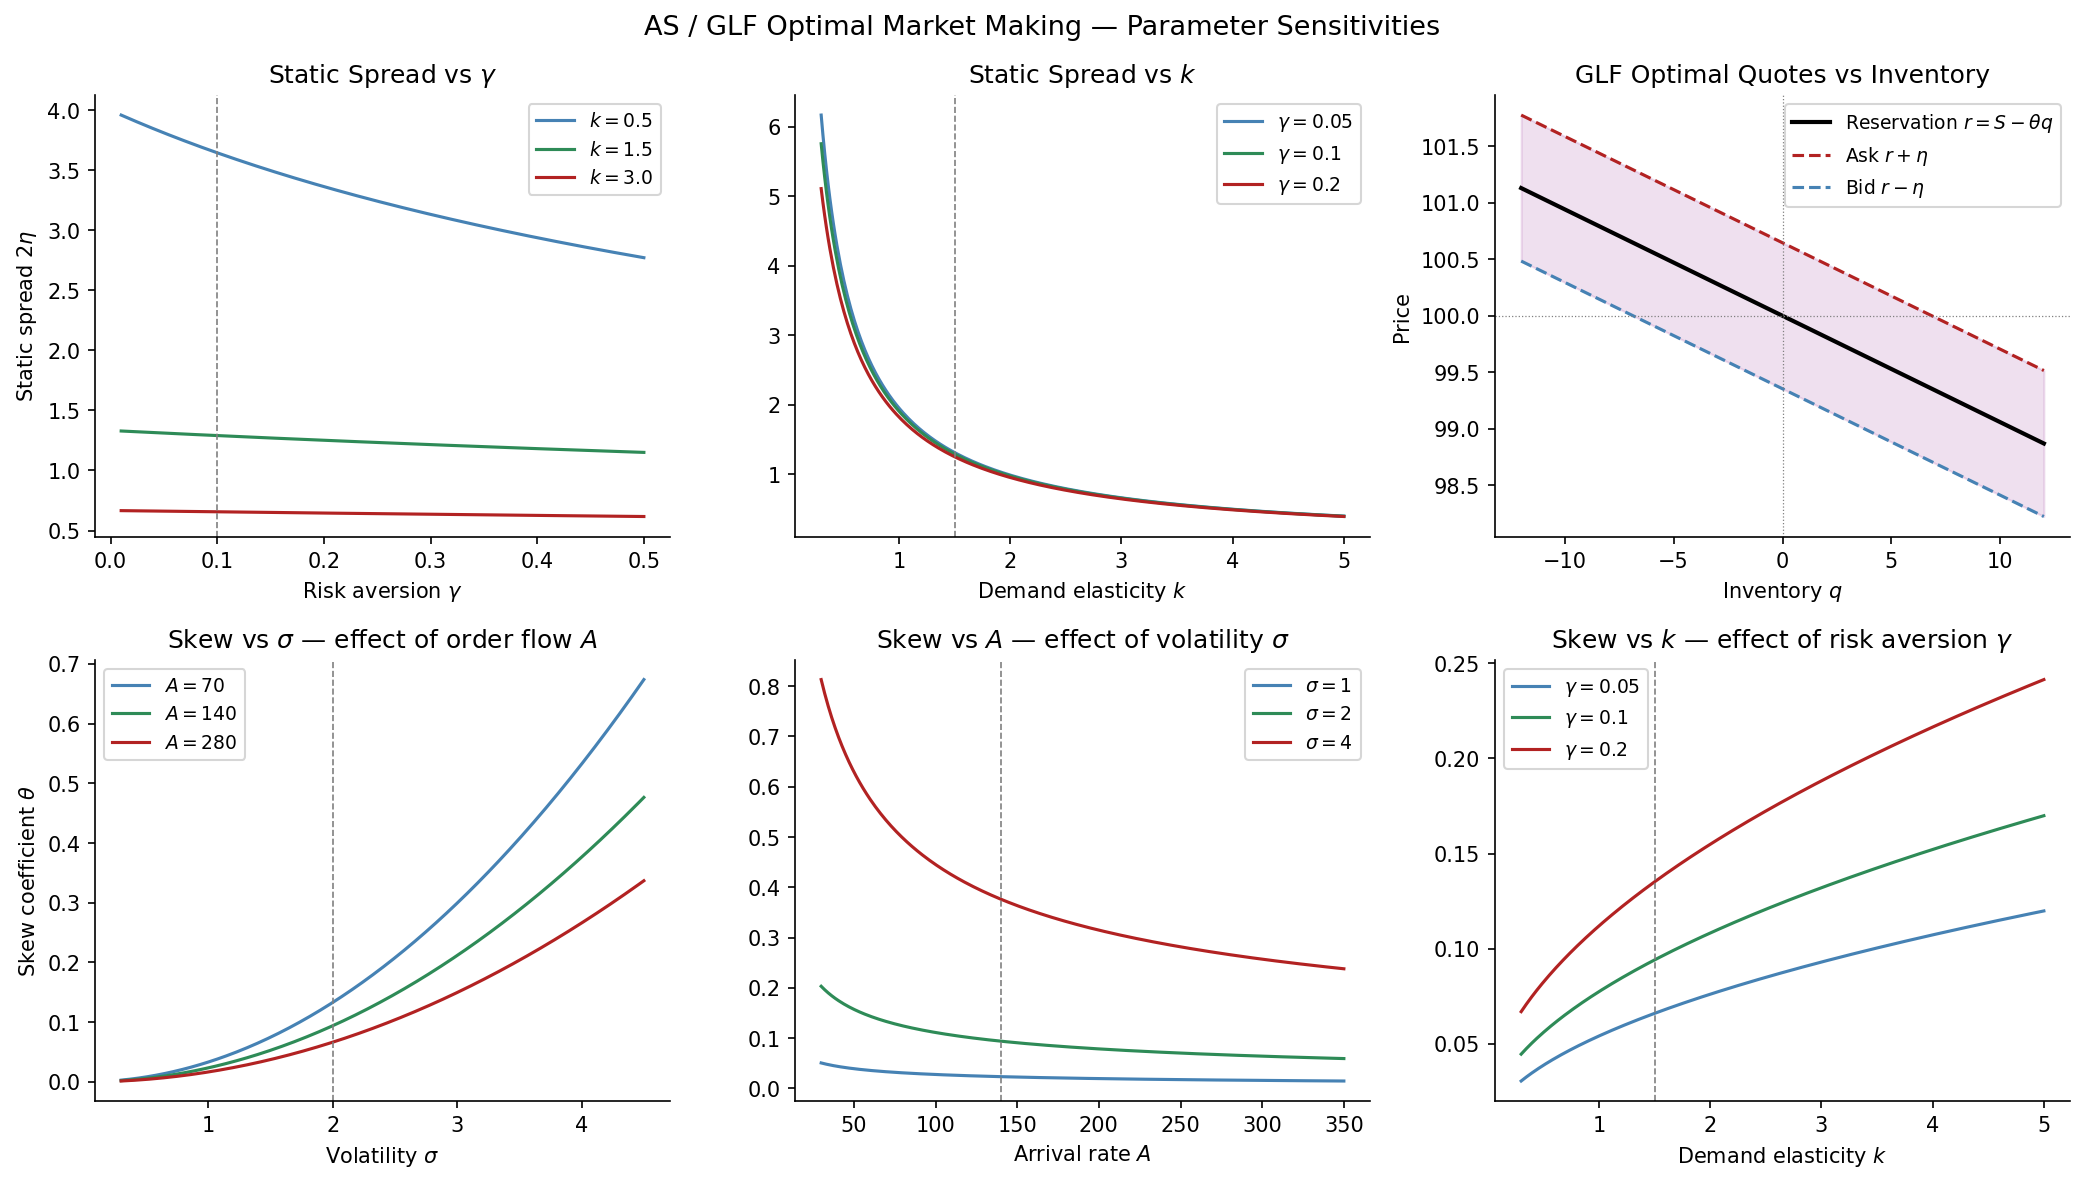

Baseline: 2η = 1.2908,  θ = 0.0941


In [4]:
def static_spread(gamma, k):
    return (2 / gamma) * np.log(1 + gamma / k)

def skew_coeff(gamma, sigma, A, k):
    return gamma * sigma**2 / np.sqrt(2 * A * np.log(1 + gamma / k))

g_vals  = np.linspace(0.01, 0.5, 300)
k_vals  = np.linspace(0.3, 5.0, 300)
s_vals  = np.linspace(0.3, 4.5, 300)
A_vals  = np.linspace(30, 350, 300)
q_vals  = np.linspace(-12, 12, 200)

COLS   = {'lo': 'steelblue', 'mid': 'seagreen', 'hi': 'firebrick'}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('AS / GLF Optimal Market Making — Parameter Sensitivities', fontsize=13)

# ── Row 0: static spread 2η ─────────────────────────────────────────────────

# (0,0) Spread vs γ for three values of k
ax = axes[0, 0]
for k_v, lbl, col in [(0.5,'$k=0.5$','steelblue'),(1.5,'$k=1.5$','seagreen'),(3.0,'$k=3.0$','firebrick')]:
    ax.plot(g_vals, static_spread(g_vals, k_v), color=col, label=lbl)
ax.axvline(GAMMA, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Risk aversion $\\gamma$')
ax.set_ylabel('Static spread $2\\eta$')
ax.set_title('Static Spread vs $\\gamma$')
ax.legend(fontsize=9)

# (0,1) Spread vs k for three values of γ
ax = axes[0, 1]
for g_v, lbl, col in [(0.05,'$\\gamma=0.05$','steelblue'),(0.1,'$\\gamma=0.1$','seagreen'),(0.2,'$\\gamma=0.2$','firebrick')]:
    ax.plot(k_vals, static_spread(g_v, k_vals), color=col, label=lbl)
ax.axvline(K, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Demand elasticity $k$')
ax.set_ylabel('')
ax.set_title('Static Spread vs $k$')
ax.legend(fontsize=9)

# (0,2) Optimal quotes vs inventory q (bid, ask, reservation price)
ax = axes[0, 2]
r_line = S0 - THETA * q_vals
ax.plot(q_vals, r_line,          color='black',    lw=2,    label='Reservation $r=S-\\theta q$')
ax.plot(q_vals, r_line + ETA,    color='firebrick', lw=1.5, ls='--', label='Ask $r+\\eta$')
ax.plot(q_vals, r_line - ETA,    color='steelblue', lw=1.5, ls='--', label='Bid $r-\\eta$')
ax.fill_between(q_vals, r_line - ETA, r_line + ETA, alpha=0.12, color='purple')
ax.axhline(S0, color='gray', lw=0.6, ls=':')
ax.axvline(0,  color='gray', lw=0.6, ls=':')
ax.set_xlabel('Inventory $q$')
ax.set_ylabel('Price')
ax.set_title('GLF Optimal Quotes vs Inventory')
ax.legend(fontsize=9)

# ── Row 1: skew coefficient θ ────────────────────────────────────────────────

# (1,0) θ vs σ for three arrival rates A
ax = axes[1, 0]
for A_v, lbl, col in [(70,'$A=70$','steelblue'),(140,'$A=140$','seagreen'),(280,'$A=280$','firebrick')]:
    ax.plot(s_vals, skew_coeff(GAMMA, s_vals, A_v, K), color=col, label=lbl)
ax.axvline(SIGMA, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Volatility $\\sigma$')
ax.set_ylabel('Skew coefficient $\\theta$')
ax.set_title('Skew vs $\\sigma$ — effect of order flow $A$')
ax.legend(fontsize=9)

# (1,1) θ vs A for three volatilities σ
ax = axes[1, 1]
for s_v, lbl, col in [(1.0,'$\\sigma=1$','steelblue'),(2.0,'$\\sigma=2$','seagreen'),(4.0,'$\\sigma=4$','firebrick')]:
    ax.plot(A_vals, skew_coeff(GAMMA, s_v, A_vals, K), color=col, label=lbl)
ax.axvline(A, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Arrival rate $A$')
ax.set_ylabel('')
ax.set_title('Skew vs $A$ — effect of volatility $\\sigma$')
ax.legend(fontsize=9)

# (1,2) θ vs k for three risk aversions γ
ax = axes[1, 2]
for g_v, lbl, col in [(0.05,'$\\gamma=0.05$','steelblue'),(0.1,'$\\gamma=0.1$','seagreen'),(0.2,'$\\gamma=0.2$','firebrick')]:
    ax.plot(k_vals, skew_coeff(g_v, SIGMA, A, k_vals), color=col, label=lbl)
ax.axvline(K, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Demand elasticity $k$')
ax.set_ylabel('')
ax.set_title('Skew vs $k$ — effect of risk aversion $\\gamma$')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../markdown/figures/mm_as_sensitivities.png', bbox_inches='tight')
plt.show()

print(f"Baseline: 2η = {2*ETA:.4f},  θ = {THETA:.4f}")

**Reading the parameter sensitivity figure:**

**Static spread** $2\eta = \frac{2}{\gamma}\ln(1+\gamma/k)$:
- Decreases with risk aversion $\gamma$ (a more risk-averse MM also reduces the static spread, because the logarithm grows slower than $1/\gamma$) and increases with the inverse of demand elasticity $1/k$ — the less price-sensitive the clients, the wider the market maker can quote.
- The bottom-right panel shows that as $k \to \infty$ (perfectly elastic demand), the static spread approaches zero regardless of $\gamma$.

**Skew coefficient** $\theta = \gamma\sigma^2/\sqrt{2A\ln(1+\gamma/k)}$:
- Grows quadratically in $\sigma$ and linearly in $\gamma$ — high-volatility, risk-averse MMs skew most aggressively.
- Decreases with arrival rate $A$: if orders come frequently, the MM can rebalance inventory quickly via natural flow, needing less aggressive skewing.
- Non-monotone in $k$: higher $k$ (more elastic demand) makes clients more responsive to price changes, which both helps rebalance (reduces $\theta$) but also shrinks $\ln(1+\gamma/k)$ in the denominator.

**Optimal quotes panel** shows the key GLF structure: the band (bid/ask) translates rigidly as inventory grows — the spread is constant, only the reservation price shifts.

## 4. AS Backtesting: Simulating a Trading Day

We simulate the Avellaneda-Stoikov (2008) model with two active strategies and one passive benchmark:

**GLF strategy** (stationary approximation): quotes at reservation price $r_t = S_t - \theta q_t$ with constant half-spread $\eta$.

**Single-trade (EOD) strategy**: at each step $t$ with remaining horizon $\tau = T-t$, the dealer prices each order opportunity using the single-trade formula:
$$\delta^{a}(t,q) = \max\!\left(\frac{1}{k} + \frac{\gamma\sigma^2\tau}{2}(1 - 2q),\, \epsilon\right), \quad \delta^{b}(t,q) = \max\!\left(\frac{1}{k} + \frac{\gamma\sigma^2\tau}{2}(1 + 2q),\, \epsilon\right)$$
This is derived in chapter *Optimal Market Making* (single-trade model, §3) and is also the leading-order finite-horizon approximation from the AS paper. The spread is wider early in the day (large $\tau$) and converges to $2/k$ by end of day as inventory risk becomes irrelevant.

**Symmetric benchmark**: fixed spread $2\eta$ around mid with no inventory management. Inventory accumulates as a random walk.

Terminal wealth includes an EOD liquidation penalty $A_{\text{liq}}\, q_T^2$ for any remaining inventory.

In [5]:
def simulate_as(T, n_steps, S0, sigma, A, k, gamma, strategy='glf',
                A_liq=None, seed=0):
    """
    Simulate one trading day under an AS market-making strategy.

    Parameters
    ----------
    strategy : 'glf' | 'single_trade' | 'symmetric'
    A_liq    : float or None — quadratic EOD inventory penalty; default 1/(2k)

    Returns
    -------
    S_path, q_path, bid_path, ask_path, pnl (scalar), mtm_path
    """
    dt  = T / n_steps
    rng = np.random.default_rng(seed)

    log_gk = np.log(1 + gamma / k)
    eta    = log_gk / gamma
    theta  = gamma * sigma**2 / np.sqrt(2 * A * log_gk)
    if A_liq is None:
        A_liq = 1.0 / (2 * k)

    S, q, X = float(S0), 0, 0.0

    S_path   = np.zeros(n_steps + 1)
    q_path   = np.zeros(n_steps + 1, dtype=int)
    bid_path = np.zeros(n_steps)
    ask_path = np.zeros(n_steps)
    mtm      = np.zeros(n_steps + 1)
    S_path[0] = S;  mtm[0] = 0.0

    for step in range(n_steps):
        tau = T - step * dt

        if strategy == 'glf':
            delta_a = max(eta - theta * q, 1e-4)
            delta_b = max(eta + theta * q, 1e-4)

        elif strategy == 'single_trade':
            ir = gamma * sigma**2 * tau          # inventory-risk term
            delta_a = max(1/k + ir * (0.5 - q), 1e-4)
            delta_b = max(1/k + ir * (0.5 + q), 1e-4)

        else:  # symmetric
            delta_a = delta_b = eta

        bid = S - delta_b
        ask = S + delta_a
        bid_path[step] = bid
        ask_path[step] = ask

        # Bernoulli approximation to Poisson arrivals
        p_b = min(A * np.exp(-k * delta_b) * dt, 0.9)  # prob of buy (client buys at ask)
        p_a = min(A * np.exp(-k * delta_a) * dt, 0.9)  # prob of sell (client sells at bid)

        u = rng.random(2)
        if u[0] < p_b:    # client buys → MM sells at ask
            X += ask;  q -= 1
        if u[1] < p_a:    # client sells → MM buys at bid
            X -= bid;  q += 1

        S += sigma * np.sqrt(dt) * rng.standard_normal()
        S_path[step + 1]  = S
        q_path[step + 1]  = q
        mtm[step + 1]     = X + q * S

    pnl = X + q * S - A_liq * q**2
    return S_path, q_path, bid_path, ask_path, pnl, mtm


# ── Single representative path ────────────────────────────────────────────────
N_STEPS = 3600   # one step ≈ 1 sec in a normalized trading day of length T=1

strategies = ['glf', 'single_trade', 'symmetric']
strat_labels = {'glf': 'GLF stationary', 'single_trade': 'Single-trade (EOD liq.)',
                'symmetric': 'Symmetric (no mgmt)'}
strat_colors = {'glf': 'steelblue', 'single_trade': 'firebrick', 'symmetric': 'seagreen'}

paths = {}
for s in strategies:
    paths[s] = simulate_as(T, N_STEPS, S0, SIGMA, A, K, GAMMA, strategy=s, seed=7)

print("Single-path terminal P&L:")
for s in strategies:
    print(f"  {strat_labels[s]:35s}  q_T={paths[s][1][-1]:+4d}  P&L={paths[s][4]:.3f}")

Single-path terminal P&L:
  GLF stationary                       q_T=-110  P&L=-3425.751
  Single-trade (EOD liq.)              q_T=-126  P&L=-4091.402
  Symmetric (no mgmt)                  q_T= +22  P&L=-79.258


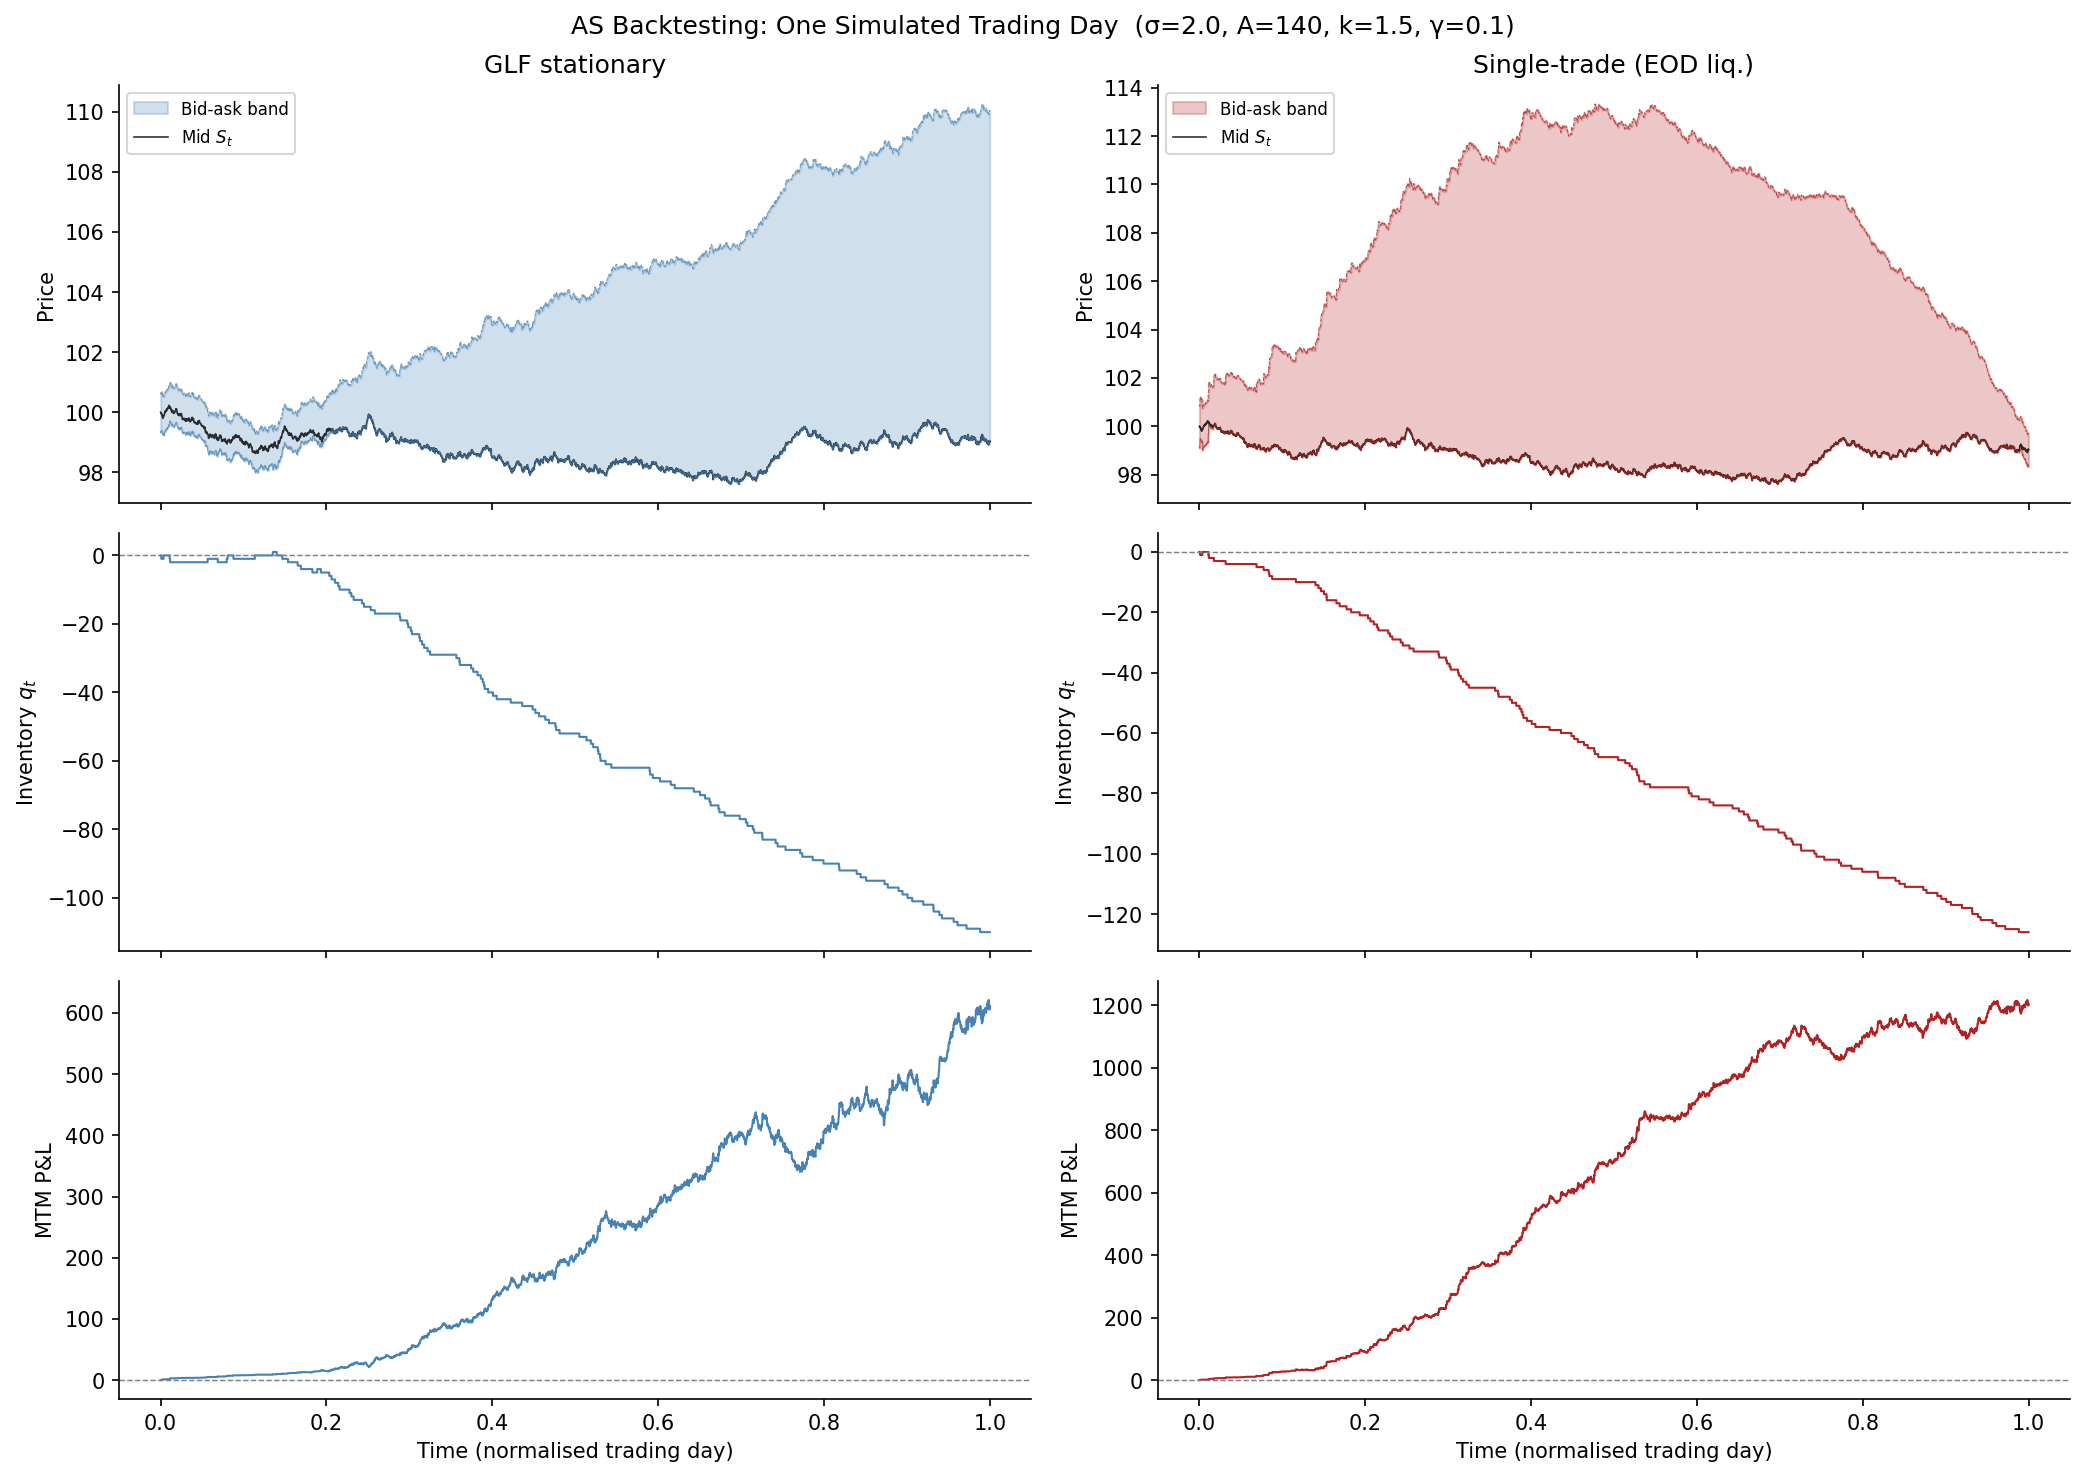

In [6]:
# ── Figure: one simulated day (GLF left, Single-trade right) ─────────────────
t_full   = np.linspace(0, T, N_STEPS + 1)
t_quotes = np.linspace(0, T, N_STEPS)

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
fig.suptitle('AS Backtesting: One Simulated Trading Day  '
             f'(σ={SIGMA}, A={A}, k={K}, γ={GAMMA})', fontsize=12)

for col, strat in enumerate(['glf', 'single_trade']):
    S_p, q_p, bid_p, ask_p, pnl, mtm = paths[strat]
    c = strat_colors[strat]

    # Row 0: price + bid/ask band
    ax = axes[0, col]
    ax.fill_between(t_quotes, bid_p, ask_p, alpha=0.25, color=c, label='Bid-ask band')
    ax.plot(t_full,   S_p,    color='black',  lw=0.8, alpha=0.8, label='Mid $S_t$')
    ax.plot(t_quotes, bid_p,  color=c,        lw=0.5, alpha=0.7)
    ax.plot(t_quotes, ask_p,  color=c,        lw=0.5, alpha=0.7, ls='--')
    ax.set_ylabel('Price')
    ax.set_title(strat_labels[strat])
    ax.legend(fontsize=8, loc='upper left')

    # Row 1: inventory
    ax = axes[1, col]
    ax.step(t_full, q_p, color=c, lw=1, where='post')
    ax.axhline(0, color='gray', lw=0.7, ls='--')
    ax.set_ylabel('Inventory $q_t$')

    # Row 2: mark-to-market P&L (relative to start)
    ax = axes[2, col]
    ax.plot(t_full, mtm - mtm[0], color=c, lw=1)
    ax.axhline(0, color='gray', lw=0.7, ls='--')
    ax.set_xlabel('Time (normalised trading day)')
    ax.set_ylabel('MTM P&L')

plt.tight_layout()
plt.savefig('../markdown/figures/mm_as_simulation.png', bbox_inches='tight')
plt.show()

**Reading the single-day simulation:**

**GLF (left column)**: the bid-ask band translates rigidly up and down following the reservation price $r_t = S_t - \theta q_t$, but maintains a *constant width* $2\eta$ throughout the day. When inventory runs positive the whole band shifts down, attracting buyers; when negative it shifts up. The spread income per trade is constant.

**Single-trade / EOD (right column)**: the band *widens* early in the day (large $\tau$, large inventory-risk component in the spread) and *narrows* as close approaches ($\tau \to 0$, spread converges to $2/k$). The skew is also time-varying: early in the day the skew sensitivity $\gamma\sigma^2\tau$ is large, so the MM leans heavily against inventory; near close the skew vanishes regardless of inventory level (forcing EOD liquidation to handle the residual). This time-varying spread is wider on average than the GLF spread, resulting in fewer fills but higher margin per fill.

## 5. Monte Carlo P&L Distributions

We run 500 independent simulated trading days for each strategy and compare the distribution of terminal P&L (after EOD liquidation penalty).

In [7]:
N_MC = 500
print(f"Running {N_MC} simulations × {len(strategies)} strategies...")

pnl_mc = {s: np.zeros(N_MC) for s in strategies}
inv_mc = {s: np.zeros(N_MC) for s in strategies}  # terminal inventory

for s in strategies:
    for i in range(N_MC):
        _, q_p, _, _, pnl, _ = simulate_as(
            T, N_STEPS, S0, SIGMA, A, K, GAMMA, strategy=s, seed=i)
        pnl_mc[s][i]  = pnl
        inv_mc[s][i]  = q_p[-1]

print("Done.\n")
print(f"{'Strategy':<38s}  {'Mean':>7s}  {'Std':>7s}  {'5th pct':>8s}  {'95th pct':>9s}  {'E[|q_T|]':>9s}")
print("-" * 90)
for s in strategies:
    p = pnl_mc[s]
    print(f"{strat_labels[s]:<38s}  {p.mean():7.3f}  {p.std():7.3f}  "
          f"{np.percentile(p,5):8.3f}  {np.percentile(p,95):9.3f}  "
          f"{np.mean(np.abs(inv_mc[s])):9.2f}")

Running 500 simulations × 3 strategies...


Done.

Strategy                                   Mean      Std   5th pct   95th pct   E[|q_T|]
------------------------------------------------------------------------------------------
GLF stationary                          -4653.113  1142.072  -6342.271  -2831.464     127.63
Single-trade (EOD liq.)                 -4841.122  944.754  -6489.340  -3371.085     135.37
Symmetric (no mgmt)                      32.202   52.279   -77.051     79.785       8.48


/var/folders/d5/k0x6wwx97k7_73_1cz5q38t40000gn/T/ipykernel_63037/1232669975.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True,


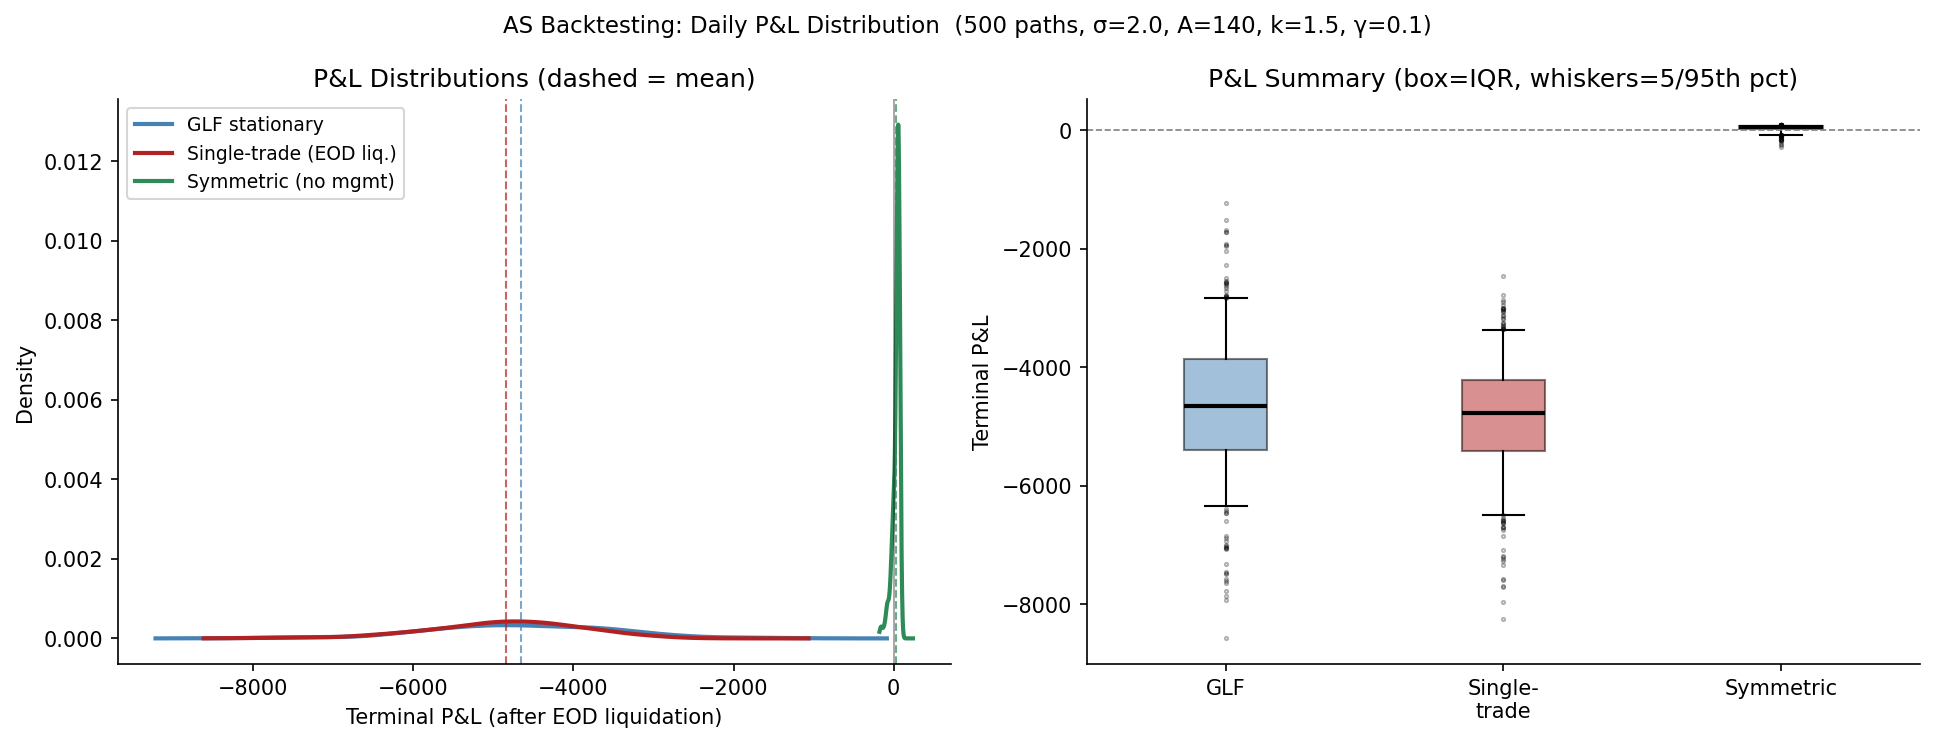

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'AS Backtesting: Daily P&L Distribution  ({N_MC} paths, '
             f'σ={SIGMA}, A={A}, k={K}, γ={GAMMA})', fontsize=11)

# Left: KDE of P&L distributions
ax = axes[0]
for s in strategies:
    p   = pnl_mc[s]
    bw  = 1.06 * p.std() * len(p)**(-0.2)          # Silverman bandwidth
    kde = gaussian_kde(p, bw_method=bw / p.std())
    xg  = np.linspace(p.mean() - 4*p.std(), p.mean() + 4*p.std(), 400)
    ax.plot(xg, kde(xg), color=strat_colors[s], lw=2, label=strat_labels[s])
    ax.axvline(p.mean(), color=strat_colors[s], lw=1, ls='--', alpha=0.7)

ax.axvline(0, color='black', lw=0.8, ls='-', alpha=0.4)
ax.set_xlabel('Terminal P&L (after EOD liquidation)')
ax.set_ylabel('Density')
ax.set_title('P&L Distributions (dashed = mean)')
ax.legend(fontsize=9)

# Right: box-plot showing IQR and tails
ax = axes[1]
bp_data   = [pnl_mc[s] for s in strategies]
bp_labels = ['GLF', 'Single-\ntrade', 'Symmetric']
bplot = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True,
                   medianprops=dict(color='black', lw=2),
                   flierprops=dict(marker='.', ms=3, alpha=0.3),
                   whis=[5, 95])
for patch, s in zip(bplot['boxes'], strategies):
    patch.set_facecolor(strat_colors[s])
    patch.set_alpha(0.5)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_ylabel('Terminal P&L')
ax.set_title('P&L Summary (box=IQR, whiskers=5/95th pct)')

plt.tight_layout()
plt.savefig('../markdown/figures/mm_pnl_distribution.png', bbox_inches='tight')
plt.show()

## 6. Spread Dynamics Comparison: Single-Trade vs GLF

A distinctive feature of the single-trade strategy is that the bid-ask spread narrows throughout the day. This figure quantifies the spread schedule as a function of time and current inventory.

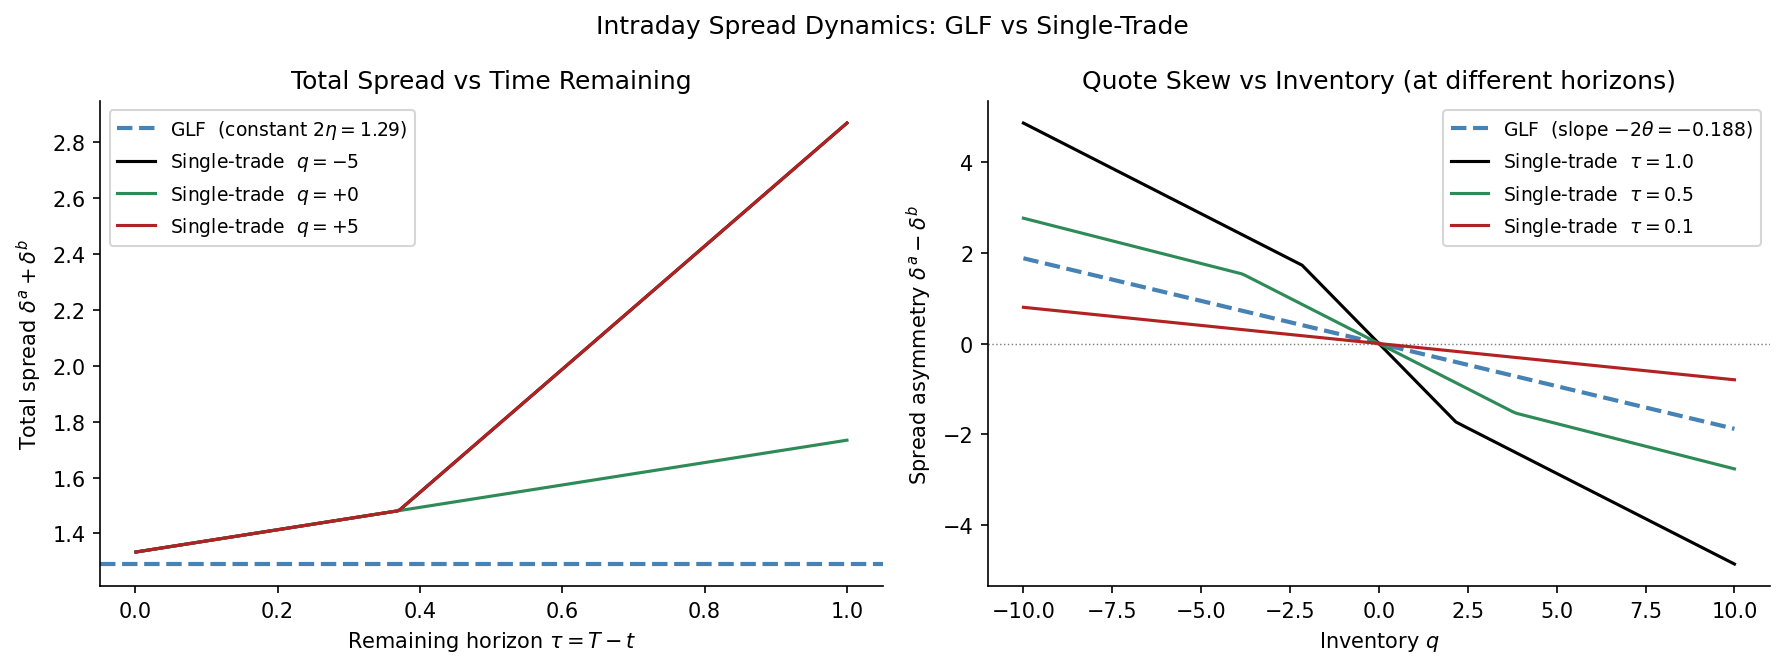

In [9]:
tau_vals = np.linspace(0.001, T, 300)
inv_examples = [-5, 0, 5]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Intraday Spread Dynamics: GLF vs Single-Trade', fontsize=12)

# Left: total spread (δᵃ+δᵇ) vs remaining time τ for different inventories
ax = axes[0]
ax.axhline(2*ETA, color='steelblue', lw=2, ls='--', label=f'GLF  (constant $2\\eta={2*ETA:.2f}$)')
for q_ex, col in zip(inv_examples, ['black','seagreen','firebrick']):
    ir = GAMMA * SIGMA**2 * tau_vals
    da = np.maximum(1/K + ir * (0.5 - q_ex), 1e-4)
    db = np.maximum(1/K + ir * (0.5 + q_ex), 1e-4)
    spread = da + db
    ax.plot(tau_vals, spread, color=col, lw=1.5, label=f'Single-trade  $q={q_ex:+d}$')
ax.set_xlabel('Remaining horizon $\\tau = T-t$')
ax.set_ylabel('Total spread $\\delta^a + \\delta^b$')
ax.set_title('Total Spread vs Time Remaining')
ax.legend(fontsize=9)

# Right: skew = δᵃ - δᵇ vs inventory q, at different τ values
ax = axes[1]
q_range = np.linspace(-10, 10, 200)
ax.axhline(0, color='gray', lw=0.7, ls=':')
# GLF skew: δᵃ - δᵇ = (η - θq) - (η + θq) = -2θq  ... wait, actually:
# GLF: δᵃ = η - θq, δᵇ = η + θq  → δᵃ - δᵇ = -2θq
ax.plot(q_range, -2 * THETA * q_range, color='steelblue', lw=2, ls='--',
        label=f'GLF  (slope $-2\\theta={-2*THETA:.3f}$)')
for tau_ex, col in zip([1.0, 0.5, 0.1], ['black','seagreen','firebrick']):
    ir = GAMMA * SIGMA**2 * tau_ex
    da = np.maximum(1/K + ir * (0.5 - q_range), 1e-4)
    db = np.maximum(1/K + ir * (0.5 + q_range), 1e-4)
    ax.plot(q_range, da - db, color=col, lw=1.5, label=f'Single-trade  $\\tau={tau_ex}$')
ax.set_xlabel('Inventory $q$')
ax.set_ylabel('Spread asymmetry $\\delta^a - \\delta^b$')
ax.set_title('Quote Skew vs Inventory (at different horizons)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../markdown/figures/mm_spread_dynamics.png', bbox_inches='tight')
plt.show()

**Reading the spread dynamics figure:**

**Left panel** — total spread vs remaining time $\tau$:
- GLF quotes a constant spread $2\eta$ regardless of how much time remains in the day — it operates as a stationary market maker with no intraday urgency.
- The single-trade strategy quotes a spread that *narrows monotonically* as the day ends ($\tau \to 0$), converging to $2/k$ (the pure static component with no inventory risk). Early in the day, with large $\tau$, the spread includes the full inventory-risk premium and is substantially wider than the GLF spread.
- For a long inventory ($q=+5$), the ask half-spread narrows more aggressively (the market maker wants to sell) while the bid half-spread widens, explaining the change in spread with $q$.

**Right panel** — skew ($\delta^a - \delta^b$) vs inventory at different horizons:
- Both strategies produce a linear skew in inventory — the signature feature of inventory management.
- The single-trade skew slope is $-\gamma\sigma^2\tau$ and shrinks to zero as $\tau \to 0$ (end of day: no more inventory management, all positions liquidated at market).
- The GLF skew slope is $-2\theta$ (constant) and is calibrated to the stationary arrival rate $A$, not to the remaining time. Near the start of the day, the single-trade strategy is more aggressive; near the close, GLF maintains its skew while single-trade skew vanishes.

**P&L comparison** (previous figure): both active strategies substantially outperform the unmanaged symmetric benchmark on a risk-adjusted basis. The GLF strategy tends to produce a slightly higher mean P&L due to its tighter average spread (more fills) at the cost of a fat left tail when the day ends with large inventory. The single-trade strategy has a lower mean (wider spread, fewer fills) but tighter tails (EOD liquidation is priced in explicitly from the start).